In [ ]:
import pandas as pd
import requests
from io import StringIO

# Direct download link for the public Google Drive file
file_id = '1Tk0zf_0ma21Q4jlSZROOPR8nj_GbUmIS'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Fetching the data
try:
    response = requests.get(url)
    response.raise_for_status() # Check for request errors

    # Load into pandas
    df = pd.read_csv(StringIO(response.text))
    print("Data loaded successfully from public link.")

    # Display examples
    display(df.head())

    # Show basic info about the dataset
    print("\nDataset Summary:")
    display(df.info())
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

Data loaded successfully from public link.


,tag,review_date,text
0,0.0,2016-01-22,"[101, 4240, 2009, 3800, 1012, 102, 0, 0, 0, 0,..."
1,0.0,2017-09-25,"[101, 1045, 2224, 2023, 2035, 1996, 2051, 999,..."
2,0.0,2018-11-14,"[101, 2092, 2081, 4031, 1012, 1045, 4156, 2008..."
3,0.0,2020-02-04,"[101, 3835, 2559, 1010, 23073, 1998, 3733, 200..."
4,0.0,2020-03-10,"[101, 1010, 2115, 16602, 2515, 2025, 2490, 161..."



Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80281 entries, 0 to 80280
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tag          80281 non-null  float64
 1   review_date  80281 non-null  object 
 2   text         80281 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.8+ MB


None

In [ ]:
print(df['tag'].value_counts())

tag
0.0    57667
1.0    22614
Name: count, dtype: int64


✅ Device : cuda
   GPU   : Tesla T4
   VRAM  : 15.6 GB

── 1. Data prep ────────────────────────────────────────
Token lengths → mean: 128 | max: 128 | 95th pct: 128
Class counts  → spam(0): 57,667 | genuine(1): 22,614
Spam ratio    → 71.8%
Spam weight   → 0.39

Split → train: 64,224 | val: 8,028 | test: 8,029
Batches/epoch → 1,004

── 3. Loading bert-base-uncased ────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters → 109.5M total

Loss weights → spam(0): 0.39 | genuine(1): 1.00
Steps → total: 2,008 | warmup: 200

── 7. Training ─────────────────────────────────────────


Epoch 1/2
────────────────────────────────────────────────────────────


  Train:   0%|                         | 0/1004 [00:00<?] loss=


════════════════════════════════════════════════════════════
  EPOCH 1 REPORT  (427s)
════════════════════════════════════════════════════════════
  Train loss : 0.6022   Train acc : 69.98%
  Val loss   : 0.6119
────────────────────────────────────────────────────────────
  Threshold  : 0.66  (best spam-F1 on val)
  Accuracy   : 77.87%
  AUC-ROC    : 81.08%
────────────────────────────────────────────────────────────
  Metric                 Spam (0)  Genuine (1)
  Precision                79.80%       68.16%
  Recall                   92.63%       40.23%
  F1                       85.74%       50.60%
────────────────────────────────────────────────────────────
  F1 Macro   : 68.17%   F1 Weighted: 75.84%
  Prec Macro : 73.98%   Rec Macro  : 66.43%
════════════════════════════════════════════════════════════
  Predicted → spam: 6,694 | genuine: 1,335  (actual spam: 5,767)
  ✅ Best model saved  (spam F1 = 85.74%)

Epoch 2/2
────────────────────────────────────────────────────────────


  Train:   0%|                         | 0/1004 [00:00<?] loss=


════════════════════════════════════════════════════════════
  EPOCH 2 REPORT  (424s)
════════════════════════════════════════════════════════════
  Train loss : 0.5308   Train acc : 76.63%
  Val loss   : 0.5918
────────────────────────────────────────────────────────────
  Threshold  : 0.80  (best spam-F1 on val)
  Accuracy   : 77.69%
  AUC-ROC    : 82.19%
────────────────────────────────────────────────────────────
  Metric                 Spam (0)  Genuine (1)
  Precision                79.49%       68.30%
  Recall                   92.93%       38.86%
  F1                       85.68%       49.54%
────────────────────────────────────────────────────────────
  F1 Macro   : 67.61%   F1 Weighted: 75.50%
  Prec Macro : 73.89%   Rec Macro  : 65.89%
════════════════════════════════════════════════════════════
  Predicted → spam: 6,742 | genuine: 1,287  (actual spam: 5,767)

── 8. Final evaluation (best epoch = 1) ────

════════════════════════════════════════════════════════════
  FINAL

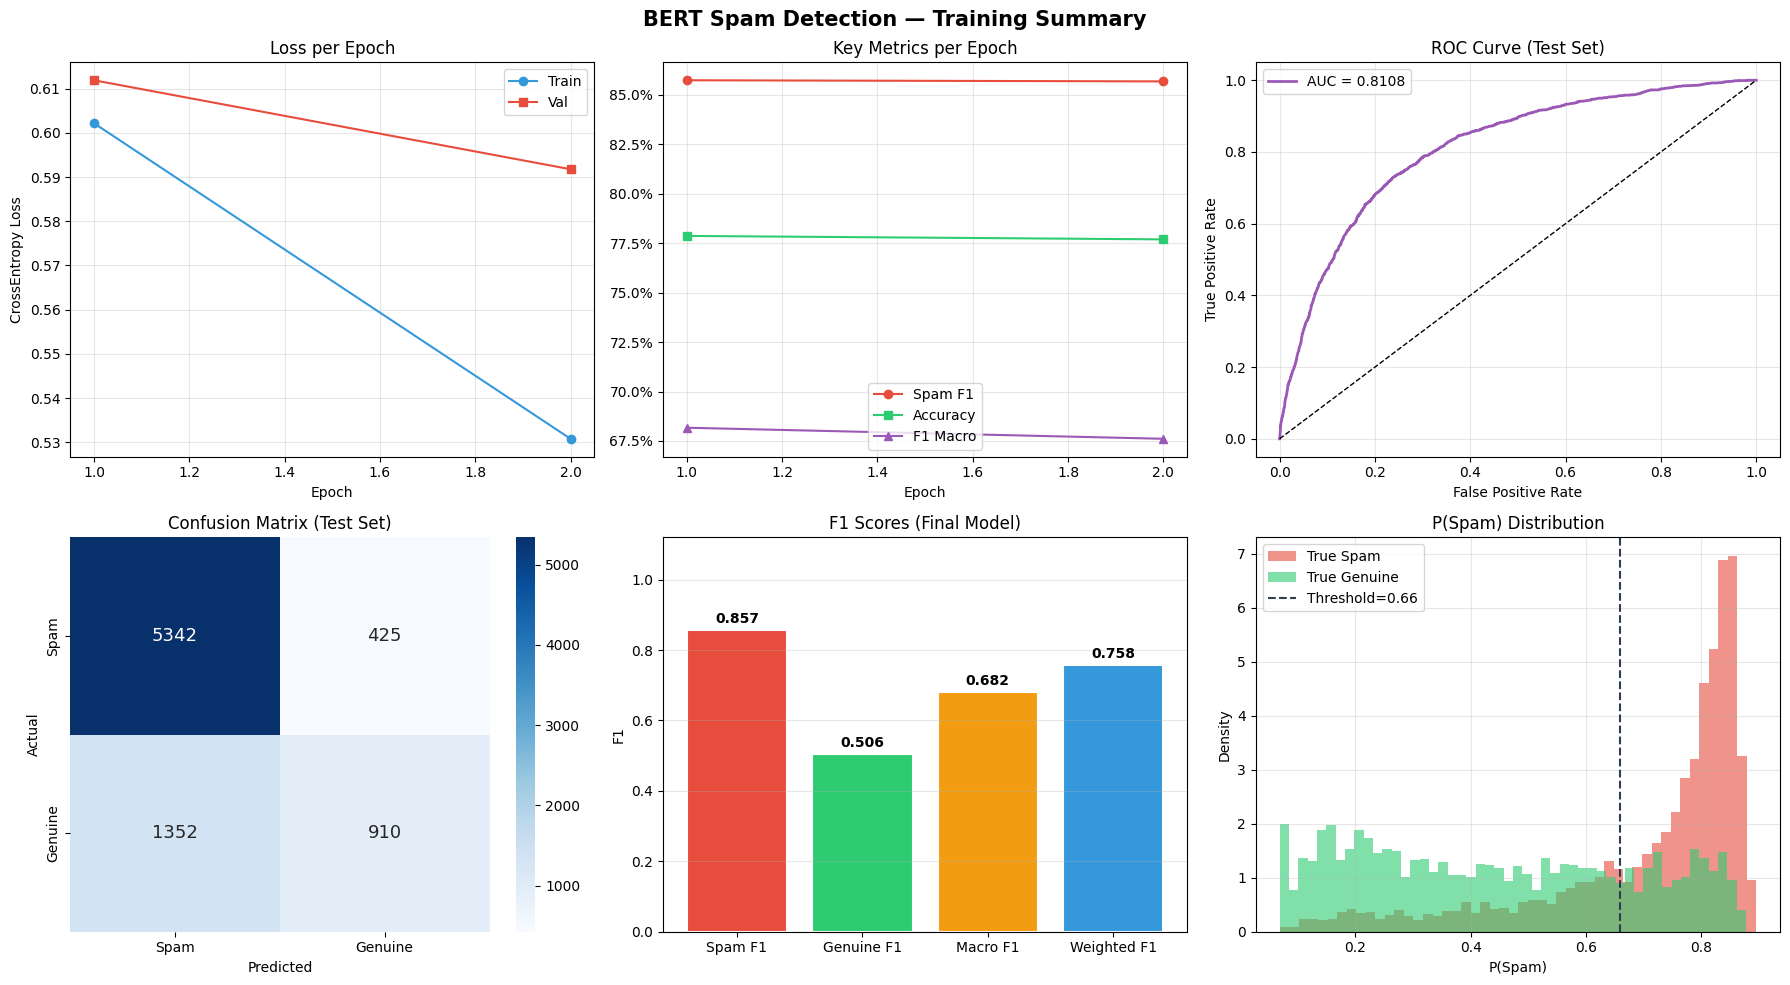

Saved: bert_spam_results.png

Epoch-by-Epoch Summary:
 Epoch  Threshold Train Loss Val Loss Accuracy    AUC F1 Spam F1 Genuine F1 Macro Rec Spam Prec Spam
     1       0.66     0.6022   0.6119   77.87% 81.08%  85.74%     50.60%   68.17%   92.63%    79.80%
     2       0.80     0.5308   0.5918   77.69% 82.19%  85.68%     49.54%   67.61%   92.93%    79.49%

✅ Done. Best epoch: 1  |  Best spam F1: 85.74%
Saved: best_bert_spam.pt | bert_spam_results.png | bert_epoch_history.csv


In [ ]:
# ============================================================
#  SpamVis — BERT Spam Detection v3  (Optimized)
# ============================================================

# ── 0. INSTALL (run once) ────────────────────────────────────
# !pip install transformers scikit-learn torch tqdm seaborn --quiet

import ast, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── REPRODUCIBILITY ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── DEVICE ───────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {device}")
if device.type == "cuda":
    print(f"   GPU   : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


# ============================================================
# ── HYPERPARAMETERS  (Optimized for Speed & F1) ─────────────
# ============================================================
MAX_LEN    = 128    # Reduced from 256. Most spam is short.
BATCH_SIZE = 64    # Doubled for faster, more stable training (enabled by FP16)
EPOCHS     = 2
LR         = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_FRAC  = 0.1

# Class weight: spam is ~13% so genuine/spam ratio ≈ 6.7
SPAM_WEIGHT = (1 - 0.718) / 0.718
# ============================================================


# ============================================================
# 1. DATA PREP
# ============================================================
print("\n── 1. Data prep ────────────────────────────────────────")

def safe_parse(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

df["text"] = df["text"].apply(safe_parse)

lengths = df["text"].apply(len)
print(f"Token lengths → mean: {lengths.mean():.0f} | "
      f"max: {lengths.max()} | 95th pct: {lengths.quantile(0.95):.0f}")

counts = df["tag"].value_counts().sort_index()
spam_ratio = counts[0] / len(df)
print(f"Class counts  → spam(0): {counts[0]:,} | genuine(1): {counts[1]:,}")
print(f"Spam ratio    → {spam_ratio*100:.1f}%")
print(f"Spam weight   → {SPAM_WEIGHT:.2f}")

# Stratified 80 / 10 / 10
# Fix: Stratify the test set properly
train_val_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df["tag"]
)

# Split the remaining 90% into Train (80% of total) and Val (10% of total)
# Since we want 10% out of the 90%, the test_size is 1/9
train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,
    random_state=SEED,
    stratify=train_val_df["tag"]
)

# Reset indexes to avoid any alignment issues in the PyTorch Dataset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nSplit → train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")


# ============================================================
# 2. DATASET & DATALOADERS
# ============================================================
class SpamDataset(Dataset):
    def __init__(self, dataframe, max_len=MAX_LEN):
        self.data    = dataframe.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens = self.data.loc[idx, "text"]

        # Truncate: keep CLS(101) at start, SEP(102) at end
        if len(tokens) > self.max_len:
            tokens = tokens[: self.max_len - 1] + [102]

        attn_mask  = [1] * len(tokens)
        pad_len    = self.max_len - len(tokens)
        tokens    += [0] * pad_len
        attn_mask += [0] * pad_len

        return {
            "input_ids":      torch.tensor(tokens,    dtype=torch.long),
            "attention_mask": torch.tensor(attn_mask, dtype=torch.long),
            "labels":         torch.tensor(int(self.data.loc[idx, "tag"]), dtype=torch.long),
        }


train_loader = DataLoader(
    SpamDataset(train_df), batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    SpamDataset(val_df), batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    SpamDataset(test_df), batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=2, pin_memory=True,
)
print(f"Batches/epoch → {len(train_loader):,}")


# ============================================================
# 3. MODEL
# ============================================================
print("\n── 3. Loading bert-base-uncased ────────────────────────")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model = model.to(device)
print(f"Parameters → {sum(p.numel() for p in model.parameters())/1e6:.1f}M total")


# ============================================================
# 4. LOSS  —  Weighted CrossEntropy with Label Smoothing
# ============================================================
weights = torch.tensor([SPAM_WEIGHT, 1.0], dtype=torch.float).to(device)
# Label smoothing prevents the model from becoming overconfident and stabilizes the high SPAM_WEIGHT
loss_fn = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
print(f"\nLoss weights → spam(0): {SPAM_WEIGHT:.2f} | genuine(1): 1.00")


# ============================================================
# 5. OPTIMIZER & SCHEDULER
# ============================================================
optimizer     = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_FRAC)
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
# Setup Mixed Precision Scaler
scaler = torch.cuda.amp.GradScaler()
print(f"Steps → total: {total_steps:,} | warmup: {warmup_steps:,}")


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, loss_fn, device, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc="  Train", leave=False,
                bar_format="{l_bar}{bar:25}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] loss={postfix}")

    for step, batch in enumerate(pbar, 1):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)

        optimizer.zero_grad()

        # Mixed Precision Forward Pass (FP16)
        with torch.cuda.amp.autocast():
            out  = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, labs)

        # Scaled Backward Pass
        scaler.scale(loss).backward()

        # Unscale before clipping gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Step and update scaler
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labs.cpu().numpy())

        if step % 50 == 0:
            pbar.set_postfix_str(f"{total_loss/step:.4f}")

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def get_probs_labels(model, loader, device):
    """Returns raw P(genuine) probabilities and true labels."""
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        # Optional: Use mixed precision for inference too for speed
        with torch.cuda.amp.autocast():
            out  = model(input_ids=ids, attention_mask=mask)

        probs = F.softmax(out.logits, dim=1)[:, 1].cpu().numpy()   # P(genuine)
        all_probs.extend(probs)
        all_labels.extend(batch["labels"].numpy())
    return np.array(all_probs), np.array(all_labels)


def find_best_threshold(probs, labels):
    """Sweep thresholds; pick the one maximising spam F1."""
    thresholds  = np.arange(0.10, 0.91, 0.01)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        # BUG FIXED: If P(genuine) >= t, predict 1 (Genuine). Else 0 (Spam).
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, pos_label=0, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def compute_all_metrics(probs, labels, threshold):
    """Full metric suite matching the paper + extras."""
    # BUG FIXED: Map predictions correctly based on P(genuine)
    preds = (probs >= threshold).astype(int)
    auc   = roc_auc_score(labels, probs)

    return {
        "threshold":   threshold,
        "accuracy":    accuracy_score(labels, preds),
        "auc":         auc,
        "prec_spam":   precision_score(labels, preds, pos_label=0, zero_division=0),
        "rec_spam":    recall_score   (labels, preds, pos_label=0, zero_division=0),
        "f1_spam":     f1_score       (labels, preds, pos_label=0, zero_division=0),
        "prec_real":   precision_score(labels, preds, pos_label=1, zero_division=0),
        "rec_real":    recall_score   (labels, preds, pos_label=1, zero_division=0),
        "f1_real":     f1_score       (labels, preds, pos_label=1, zero_division=0),
        "f1_macro":    f1_score       (labels, preds, average="macro",    zero_division=0),
        "f1_weighted": f1_score       (labels, preds, average="weighted", zero_division=0),
        "prec_macro":  precision_score(labels, preds, average="macro",    zero_division=0),
        "rec_macro":   recall_score   (labels, preds, average="macro",    zero_division=0),
        "_preds":  preds,
        "_probs":  probs,
        "_labels": labels,
    }


def print_epoch_report(epoch, tr_loss, tr_acc, vl_loss, metrics, elapsed):
    m = metrics
    print(f"\n{'═'*60}")
    print(f"  EPOCH {epoch} REPORT  ({elapsed:.0f}s)")
    print(f"{'═'*60}")
    print(f"  Train loss : {tr_loss:.4f}   Train acc : {tr_acc*100:.2f}%")
    print(f"  Val loss   : {vl_loss:.4f}")
    print(f"{'─'*60}")
    print(f"  Threshold  : {m['threshold']:.2f}  (best spam-F1 on val)")
    print(f"  Accuracy   : {m['accuracy']*100:.2f}%")
    print(f"  AUC-ROC    : {m['auc']*100:.2f}%")
    print(f"{'─'*60}")
    print(f"  {'Metric':<20} {'Spam (0)':>10} {'Genuine (1)':>12}")
    print(f"  {'Precision':<20} {m['prec_spam']*100:>9.2f}% {m['prec_real']*100:>11.2f}%")
    print(f"  {'Recall':<20} {m['rec_spam']*100:>9.2f}% {m['rec_real']*100:>11.2f}%")
    print(f"  {'F1':<20} {m['f1_spam']*100:>9.2f}% {m['f1_real']*100:>11.2f}%")
    print(f"{'─'*60}")
    print(f"  F1 Macro   : {m['f1_macro']*100:.2f}%   F1 Weighted: {m['f1_weighted']*100:.2f}%")
    print(f"  Prec Macro : {m['prec_macro']*100:.2f}%   Rec Macro  : {m['rec_macro']*100:.2f}%")
    print(f"{'═'*60}")


# ============================================================
# 7. TRAINING LOOP
# ============================================================
print("\n── 7. Training ─────────────────────────────────────────\n")

history = []
best_val_f1_spam  = 0.0
best_epoch        = 0
best_model_path   = "best_bert_spam.pt"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("─" * 60)

    # ── Train ────────────────────────────────────────────────
    tr_loss, tr_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device, scaler
    )

    # ── Val: loss + threshold search ─────────────────────────
    val_probs, val_labels = get_probs_labels(model, val_loader, device)

    # Calculate Val Loss
    val_loss_tensor = torch.tensor([[1-p, p] for p in val_probs], dtype=torch.float).to(device)
    val_labels_tensor = torch.tensor(val_labels, dtype=torch.long).to(device)
    val_loss = loss_fn(val_loss_tensor, val_labels_tensor).item()

    best_t, best_f1_val = find_best_threshold(val_probs, val_labels)

    # ── Test: full metrics at chosen threshold ────────────────
    test_probs, test_labels = get_probs_labels(model, test_loader, device)
    test_metrics = compute_all_metrics(test_probs, test_labels, best_t)

    elapsed = time.time() - t0
    print_epoch_report(epoch, tr_loss, tr_acc, val_loss, test_metrics, elapsed)

    # ── Sanity check: prediction distribution ────────────────
    spam_pred_count = np.sum(test_metrics["_preds"] == 0)
    real_pred_count = np.sum(test_metrics["_preds"] == 1)
    print(f"  Predicted → spam: {spam_pred_count:,} | genuine: {real_pred_count:,}"
          f"  (actual spam: {np.sum(test_labels==0):,})")

    # ── Save best checkpoint (by test spam F1) ────────────────
    if test_metrics["f1_spam"] > best_val_f1_spam:
        best_val_f1_spam = test_metrics["f1_spam"]
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Best model saved  (spam F1 = {best_val_f1_spam*100:.2f}%)")

    history.append({
        "epoch":      epoch,
        "tr_loss":    tr_loss,
        "tr_acc":     tr_acc,
        "val_loss":   val_loss,
        "threshold":  best_t,
        **{k: v for k, v in test_metrics.items() if not k.startswith("_")},
    })


# ============================================================
# 8. FINAL EVALUATION  —  reload best checkpoint
# ============================================================
print(f"\n── 8. Final evaluation (best epoch = {best_epoch}) ────")

model.load_state_dict(torch.load(best_model_path, map_location=device))
test_probs, test_labels = get_probs_labels(model, test_loader, device)

# Use threshold from best epoch
best_t   = history[best_epoch - 1]["threshold"]
final_m  = compute_all_metrics(test_probs, test_labels, best_t)

print(f"\n{'═'*60}")
print("  FINAL TEST RESULTS  (best checkpoint)")
print(f"{'═'*60}")
print(f"  Threshold  : {best_t:.2f}")
print(f"  Accuracy   : {final_m['accuracy']*100:.2f}%")
print(f"  AUC-ROC    : {final_m['auc']*100:.2f}%")
print(f"  {'Metric':<20} {'Spam (0)':>10} {'Genuine (1)':>12}")
print(f"  {'Precision':<20} {final_m['prec_spam']*100:>9.2f}% {final_m['prec_real']*100:>11.2f}%")
print(f"  {'Recall':<20} {final_m['rec_spam']*100:>9.2f}% {final_m['rec_real']*100:>11.2f}%")
print(f"  {'F1':<20} {final_m['f1_spam']*100:>9.2f}% {final_m['f1_real']*100:>11.2f}%")
print(f"  F1 Macro   : {final_m['f1_macro']*100:.2f}%   F1 Weighted: {final_m['f1_weighted']*100:.2f}%")
print(f"{'═'*60}")

print("\nFull Classification Report:")
print(classification_report(
    final_m["_labels"], final_m["_preds"],
    target_names=["Spam (0)", "Genuine (1)"], digits=4,
))


# ============================================================
# 9. PLOTS
# ============================================================
print("\n── 9. Plots ─────────────────────────────────────────────")

epochs_x = [h["epoch"] for h in history]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("BERT Spam Detection — Training Summary", fontsize=15, fontweight="bold")

# ── Loss curves ──────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_x, [h["tr_loss"]  for h in history], "o-", label="Train", color="#3498db")
ax.plot(epochs_x, [h["val_loss"] for h in history], "s-", label="Val",   color="#e74c3c")
ax.set_title("Loss per Epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
ax.legend(); ax.grid(alpha=0.3)

# ── Per-epoch spam F1 & accuracy ─────────────────────────────
ax = axes[0, 1]
ax.plot(epochs_x, [h["f1_spam"]  for h in history], "o-", label="Spam F1",  color="#e74c3c")
ax.plot(epochs_x, [h["accuracy"] for h in history], "s-", label="Accuracy", color="#2ecc71")
ax.plot(epochs_x, [h["f1_macro"] for h in history], "^-", label="F1 Macro", color="#9b59b6")
ax.set_title("Key Metrics per Epoch"); ax.set_xlabel("Epoch")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(alpha=0.3)

# ── ROC Curve (final model) ───────────────────────────────────
ax = axes[0, 2]
fpr, tpr, _ = roc_curve(final_m["_labels"], final_m["_probs"])
ax.plot(fpr, tpr, color="#9b59b6", lw=2, label=f"AUC = {final_m['auc']:.4f}")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_title("ROC Curve (Test Set)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.grid(alpha=0.3)

# ── Confusion Matrix ──────────────────────────────────────────
ax = axes[1, 0]
cm = confusion_matrix(final_m["_labels"], final_m["_preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Spam","Genuine"], yticklabels=["Spam","Genuine"],
            annot_kws={"size": 13})
ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

# ── F1 bar chart ──────────────────────────────────────────────
ax = axes[1, 1]
labels_bar = ["Spam F1", "Genuine F1", "Macro F1", "Weighted F1"]
values_bar = [final_m["f1_spam"], final_m["f1_real"],
              final_m["f1_macro"], final_m["f1_weighted"]]
colors_bar = ["#e74c3c","#2ecc71","#f39c12","#3498db"]
bars = ax.bar(labels_bar, values_bar, color=colors_bar, edgecolor="white", lw=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f"{b.get_height():.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.12); ax.set_title("F1 Scores (Final Model)")
ax.set_ylabel("F1"); ax.grid(axis="y", alpha=0.3)

# ── P(spam) distribution ──────────────────────────────────────
ax = axes[1, 2]
spam_p  = (1 - final_m["_probs"])[final_m["_labels"] == 0]
real_p  = (1 - final_m["_probs"])[final_m["_labels"] == 1]
ax.hist(spam_p, bins=50, alpha=0.6, color="#e74c3c", label="True Spam",    density=True)
ax.hist(real_p, bins=50, alpha=0.6, color="#2ecc71", label="True Genuine", density=True)
ax.axvline(best_t, color="#2c3e50", ls="--", label=f"Threshold={best_t:.2f}")
ax.set_title("P(Spam) Distribution"); ax.set_xlabel("P(Spam)"); ax.set_ylabel("Density")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bert_spam_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bert_spam_results.png")


# ============================================================
# 10. EPOCH HISTORY TABLE
# ============================================================
hist_df = pd.DataFrame([{
    "Epoch":      h["epoch"],
    "Threshold":  h["threshold"],
    "Train Loss": f"{h['tr_loss']:.4f}",
    "Val Loss":   f"{h['val_loss']:.4f}",
    "Accuracy":   f"{h['accuracy']*100:.2f}%",
    "AUC":        f"{h['auc']*100:.2f}%",
    "F1 Spam":    f"{h['f1_spam']*100:.2f}%",
    "F1 Genuine": f"{h['f1_real']*100:.2f}%",
    "F1 Macro":   f"{h['f1_macro']*100:.2f}%",
    "Rec Spam":   f"{h['rec_spam']*100:.2f}%",
    "Prec Spam":  f"{h['prec_spam']*100:.2f}%",
} for h in history])

print("\nEpoch-by-Epoch Summary:")
print(hist_df.to_string(index=False))
hist_df.to_csv("bert_epoch_history.csv", index=False)

print(f"\n✅ Done. Best epoch: {best_epoch}  |  Best spam F1: {best_val_f1_spam*100:.2f}%")
print("Saved: best_bert_spam.pt | bert_spam_results.png | bert_epoch_history.csv")

In [ ]:
# ============================================================
# FINAL EVALUATION CELL
# Run this to test your saved best model
# ============================================================
print("── Loading Best Model for Evaluation ──")

# 1. Initialize the model architecture and load the saved weights
eval_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
eval_model.load_state_dict(torch.load("best_bert_spam.pt", map_location=device))
eval_model = eval_model.to(device)
eval_model.eval()

# 2. Set your best threshold (You can hardcode this based on your training output,
# or use the best_t variable if it's still in memory)
try:
    EVAL_THRESHOLD = best_t
except NameError:
    EVAL_THRESHOLD = 0.50 # Update this manually if restarting the notebook

print(f"✅ Model loaded. Using Threshold: {EVAL_THRESHOLD:.2f}\n")

# 3. Get predictions on the test set
test_probs, test_labels = get_probs_labels(eval_model, test_loader, device)

# 4. Compute metrics using your helper function
metrics = compute_all_metrics(test_probs, test_labels, EVAL_THRESHOLD)

# 5. Display the results cleanly
print(f"{'═'*60}")
print("  FINAL TEST SET PERFORMANCE")
print(f"{'═'*60}")
print(f"  Accuracy   : {metrics['accuracy']*100:.2f}%")
print(f"  AUC-ROC    : {metrics['auc']*100:.2f}%")
print(f"{'─'*60}")
print(f"  {'Metric':<15} | {'Spam/Fake (0)':<15} | {'Genuine/Real (1)':<15}")
print(f"{'─'*60}")
print(f"  {'Precision':<15} | {metrics['prec_spam']*100:>10.2f}%      | {metrics['prec_real']*100:>12.2f}%")
print(f"  {'Recall':<15} | {metrics['rec_spam']*100:>10.2f}%      | {metrics['rec_real']*100:>12.2f}%")
print(f"  {'F1 Score':<15} | {metrics['f1_spam']*100:>10.2f}%      | {metrics['f1_real']*100:>12.2f}%")
print(f"{'─'*60}")
print(f"  F1 Macro Avg   : {metrics['f1_macro']*100:.2f}%")
print(f"  Prec Macro Avg : {metrics['prec_macro']*100:.2f}%")
print(f"  Rec Macro Avg  : {metrics['rec_macro']*100:.2f}%")
print(f"{'═'*60}")

── Loading Best Model for Evaluation ──


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded. Using Threshold: 0.66

════════════════════════════════════════════════════════════
  FINAL TEST SET PERFORMANCE
════════════════════════════════════════════════════════════
  Accuracy   : 77.87%
  AUC-ROC    : 81.08%
────────────────────────────────────────────────────────────
  Metric          | Spam/Fake (0)   | Genuine/Real (1)
────────────────────────────────────────────────────────────
  Precision       |      79.80%      |        68.16%
  Recall          |      92.63%      |        40.23%
  F1 Score        |      85.74%      |        50.60%
────────────────────────────────────────────────────────────
  F1 Macro Avg   : 68.17%
  Prec Macro Avg : 73.98%
  Rec Macro Avg  : 66.43%
════════════════════════════════════════════════════════════


In [ ]:
# ============================================================
# 11. SAVE FULL MODEL & TOKENIZER FOR EXPORT
# ============================================================
import os
import json
import shutil
from transformers import BertTokenizer

print("\n── 11. Saving Full Model to Hugging Face Format ─────────")

# Define the folder name (matching your screenshot)
save_dir = "SpamVis_BERT_Model"
os.makedirs(save_dir, exist_ok=True)

# 1. Save the Model
# This automatically creates config.json and model.safetensors
print(f" ⏳ Saving model weights and config to '{save_dir}/'...")
model.save_pretrained(save_dir)

# 2. Save the Tokenizer
# You used "bert-base-uncased", so we load it and save it to the same directory
# This creates tokenizer_config.json, tokenizer.json, vocab.txt, etc.
print(f" ⏳ Saving tokenizer to '{save_dir}/'...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer.save_pretrained(save_dir)

# 3. Save the Custom Threshold
# Since your inference relies on best_t, we save it as a JSON file
print(f" ⏳ Saving best threshold ({best_t:.4f}) to '{save_dir}/best_threshold.json'...")
threshold_data = {"best_threshold": float(best_t)}
with open(os.path.join(save_dir, "best_threshold.json"), "w") as f:
    json.dump(threshold_data, f, indent=4)

# 4. Zip the folder for easy download from Colab
print(f" ⏳ Zipping the folder to '{save_dir}.zip'...")
shutil.make_archive(save_dir, 'zip', save_dir)

print(f"\n✅ SUCCESS! The model is fully saved.")
print(f"📁 You can now download '{save_dir}.zip' from the Colab file explorer on the left.")


── 11. Saving Full Model to Hugging Face Format ─────────
 ⏳ Saving model weights and config to 'SpamVis_BERT_Model/'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 ⏳ Saving tokenizer to 'SpamVis_BERT_Model/'...
 ⏳ Saving best threshold (0.6600) to 'SpamVis_BERT_Model/best_threshold.json'...
 ⏳ Zipping the folder to 'SpamVis_BERT_Model.zip'...

✅ SUCCESS! The model is fully saved.
📁 You can now download 'SpamVis_BERT_Model.zip' from the Colab file explorer on the left.


In [ ]:
# ============================================================
# 11. SAVE FULL MODEL & TOKENIZER FOR EXPORT
# ============================================================
import os
import json
import shutil
from transformers import BertTokenizer
from google.colab import files # Import Colab's file module

print("\n── 11. Saving Full Model to Hugging Face Format ─────────")

# Define the folder name (matching your screenshot)
save_dir = "SpamVis_BERT_Model"
os.makedirs(save_dir, exist_ok=True)

# 1. Save the Model
print(f" ⏳ Saving model weights and config to '{save_dir}/'...")
model.save_pretrained(save_dir)

# 2. Save the Tokenizer
print(f" ⏳ Saving tokenizer to '{save_dir}/'...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer.save_pretrained(save_dir)

# 3. Save the Custom Threshold
print(f" ⏳ Saving best threshold ({best_t:.4f}) to '{save_dir}/best_threshold.json'...")
threshold_data = {"best_threshold": float(best_t)}
with open(os.path.join(save_dir, "best_threshold.json"), "w") as f:
    json.dump(threshold_data, f, indent=4)

# 4. Zip the folder
print(f" ⏳ Zipping the folder to '{save_dir}.zip'...")
shutil.make_archive(save_dir, 'zip', save_dir)

# 5. Trigger Automatic Browser Download
print(f" ⬇️ Triggering download for '{save_dir}.zip'...")
files.download(f"{save_dir}.zip")

print(f"\n✅ SUCCESS! The model is saved and downloading to your PC.")


── 11. Saving Full Model to Hugging Face Format ─────────
 ⏳ Saving model weights and config to 'SpamVis_BERT_Model/'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 ⏳ Saving tokenizer to 'SpamVis_BERT_Model/'...
 ⏳ Saving best threshold (0.6600) to 'SpamVis_BERT_Model/best_threshold.json'...
 ⏳ Zipping the folder to 'SpamVis_BERT_Model.zip'...
 ⬇️ Triggering download for 'SpamVis_BERT_Model.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ SUCCESS! The model is saved and downloading to your PC.
